# Reflexion Agent

### Building a Reflection Agent with External Knowledge Integration

**Difference of Reflexion Agent from Reflection Agent is:**\
It incorporates external tools to retrieve real-time information and supports outputs with citations.


In [59]:
import os
import json
import getpass
from typing import List, Dict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, BaseMessage
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI
from langgraph.graph import END, MessageGraph, START
from IPython.display import Image, display

from dotenv import load_dotenv
load_dotenv()

True

In [60]:
llm = ChatOpenAI(model="gpt-4.1-nano")

## Tool Setup: Tavily Search

In [61]:
tavily_tool=TavilySearchResults(max_results=1)
sample_query = "healthy breakfast recipes"
search_results = tavily_tool.invoke(sample_query)
print(search_results)

[{'url': 'https://www.loveandlemons.com/healthy-breakfast-ideas/', 'content': 'Below, I share over 60 healthy breakfast recipes, divided into 11 (yes, 11!) categories: oats, eggs, smoothies, bowls, quick breads, pancakes & waffles, breakfast tacos, breakfast cookies, toast, muffins & scones, and bars & balls. Whether you’re someone who craves something savory or sweet first thing in the morning, or whether you like to enjoy breakfast at home or grab it and go, you’re sure to find some healthy breakfast ideas you love.\n\n#### Healthy Breakfast Oats\n\nOats are loaded with fiber, so they’re a great healthy breakfast! [...] #### Healthy Breakfast Smoothies\n\nSmoothies are some of the best breakfast recipes, as they pack a big serving of fruits and veggies into your first meal of the day. Through years of making smoothies, I’ve found that a handful of spinach is almost undetectable, so toss some into a fruit smoothie for extra nutrients! Alternatively, blend in a superfood like hemp seed

In [62]:
search_results

[{'url': 'https://www.loveandlemons.com/healthy-breakfast-ideas/',
  'content': 'Below, I share over 60 healthy breakfast recipes, divided into 11 (yes, 11!) categories: oats, eggs, smoothies, bowls, quick breads, pancakes & waffles, breakfast tacos, breakfast cookies, toast, muffins & scones, and bars & balls. Whether you’re someone who craves something savory or sweet first thing in the morning, or whether you like to enjoy breakfast at home or grab it and go, you’re sure to find some healthy breakfast ideas you love.\n\n#### Healthy Breakfast Oats\n\nOats are loaded with fiber, so they’re a great healthy breakfast! [...] #### Healthy Breakfast Smoothies\n\nSmoothies are some of the best breakfast recipes, as they pack a big serving of fruits and veggies into your first meal of the day. Through years of making smoothies, I’ve found that a handful of spinach is almost undetectable, so toss some into a fruit smoothie for extra nutrients! Alternatively, blend in a superfood like hemp se

## LLM and Prompting

In [63]:
question="Any ideas for a healthy breakfast"

In [ ]:
response=llm.invoke(question).content
print(response)

Certainly! Here are some healthy breakfast ideas to start your day off right:

1. Greek Yogurt with Fresh Fruit and Nuts  
2. Oatmeal topped with Berries and a drizzle of honey  
3. Whole grain toast with avocado and a poached egg  
4. Smoothie Bowl with spinach, banana, berries, and almond milk, topped with chia seeds  
5. Scrambled eggs with vegetables like spinach, tomatoes, and peppers  
6. Cottage cheese with sliced peaches and a sprinkle of flaxseeds  
7. Overnight oats prepared with milk or a dairy-free alternative, chia seeds, and your favorite fruits  
8. Quinoa breakfast bowl with nuts, seeds, and fresh fruit

Would you like recipes or specific dietary options?


## Defining the Responder

### Crafting Responder Prompt

This template makes the LLM act as a diet recommender that 
- answers, 
- critiques itself, and 
- suggests research directions
- result will always be in structured format for Reflexion improvement.

In [64]:
# prompt_template = ChatPromptTemplate.from_messages([
#     (
#         "system",
#         """You are Dr. Paul Saladino, "Carnivore MD," advocating for animal-based nutrition and challenging plant-centric dietary dogma. Focus on the superior bioavailability of animal foods and the potential toxicity of plant compounds such as oxalates, lectins, and phytates.

#         Your response must follow these steps:
#         1. {first_instruction}
#         2. Present the evolutionary and biochemical rationale for animal-based nutrition, emphasizing nutrient density, bioavailability, and the absence of plant antinutrients.
#         3. Challenge conventional "plants are healthy" narratives with mechanistic evidence about plant defense compounds and their impact on human physiology.
#         4. Reflect and critique your answer. Be rigorous about evolutionary consistency and nutrient science.
#         5. After the reflection, **list 1-3 search queries separately** for researching antinutrients, bioavailability studies, or evolutionary nutrition. Do not include them inside the reflection.

#         Focus on: organ meats as superfoods, the carnivore elimination protocol, and why "fiber is unnecessary" based on human evolutionary biology.
#         """
#     ),
#     MessagesPlaceholder(variable_name="messages"),
#     (
#         "system", 
#         "Answer the user's question above using the required format, emphasizing the superiority of animal-based nutrition."
#     ),
# ])

prompt_template_responder = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a nutrition assistant helping users choose healthy diets.

        Follow these steps: 
        1. {first_instruction}
        2. Understand the user's health condition.
        3. Suggest recommended foods.
        4. Suggest foods to avoid.
        5. Keep advice practical and safe.
        6. Provide a short explanation and Explain clearly and simply.
        7. Reflect on your answer:
           - What important information might be missing?
           - What information might be unnecessary?
        8. Provide 1–3 useful search queries for further research.

        Always think carefully before answering.
        """
    ),
    MessagesPlaceholder(variable_name="messages"),
    (
        "system",
        "You must respond using the structured tool format. Return the output using the tool schema only."
    ), # 2nd system message is for additional constraint.
])

### Invoking the responder

In [65]:
first_responder_prompt = prompt_template_responder.partial(first_instruction="Provide a detailed ~250 word answer")
temp_chain = first_responder_prompt | llm
response = temp_chain.invoke({"messages": [HumanMessage(content=question)]})
response

AIMessage(content='{\n  "answer": "A healthy breakfast should be balanced, providing a good mix of complex carbohydrates, protein, and healthy fats to fuel your day. Consider starting with whole grains like oatmeal, which offers fiber to keep you full longer and stabilize blood sugar levels. Adding a source of protein such as eggs, Greek yogurt, or nuts can support muscle repair and maintenance. Incorporate fruits like berries, bananas, or apples for natural sweetness, vitamins, and antioxidants. Including healthy fats from sources like avocado or chia seeds can also promote heart health and satiety. For example, a bowl of oatmeal topped with fresh berries, a spoon of chia seeds, and a boiled egg makes a nutritious, satisfying meal. Avoid foods high in added sugars, processed baked goods, and sugary cereals, as they can cause energy crashes and contribute to weight gain over time. Also, limit high-fat fried items or excessive dairy that may be high in saturated fats. Practical choices 

In [66]:
print(response.content) # llm responded with structures output. Because we mentioned in system prompt to do so.

{
  "answer": "A healthy breakfast should be balanced, providing a good mix of complex carbohydrates, protein, and healthy fats to fuel your day. Consider starting with whole grains like oatmeal, which offers fiber to keep you full longer and stabilize blood sugar levels. Adding a source of protein such as eggs, Greek yogurt, or nuts can support muscle repair and maintenance. Incorporate fruits like berries, bananas, or apples for natural sweetness, vitamins, and antioxidants. Including healthy fats from sources like avocado or chia seeds can also promote heart health and satiety. For example, a bowl of oatmeal topped with fresh berries, a spoon of chia seeds, and a boiled egg makes a nutritious, satisfying meal. Avoid foods high in added sugars, processed baked goods, and sugary cereals, as they can cause energy crashes and contribute to weight gain over time. Also, limit high-fat fried items or excessive dairy that may be high in saturated fats. Practical choices are easy to prepare 

### Structuring the Agent's Output

In [67]:
class Reflection(BaseModel):
	missing: str = Field(description="What information is missing")
	superfluous: str = Field(description="What information is unnecessary")

class AnswerQuestion(BaseModel):
	answer: str = Field(description="Main response to the question")
	reflection: Reflection = Field(description="Self-critique of the answer")
	search_queries: List[str] = Field(description="Queries for additional research")

### Bindings tools to the Responder

In [68]:
initial_chain = first_responder_prompt | llm.bind_tools(tools=[AnswerQuestion]) # binding llm with tool to respond with structured output as AnswerQuestion class
response=initial_chain.invoke({"messages":[HumanMessage(question)]})
print("---Full Structured Output---")
print(response.tool_calls)

---Full Structured Output---
[{'name': 'AnswerQuestion', 'args': {'answer': 'A healthy breakfast can include a variety of nutrient-rich foods that provide energy and support overall health. Consider starting your day with a bowl of oatmeal topped with fresh fruits and a sprinkle of nuts or seeds. This combination offers complex carbohydrates, fiber, healthy fats, and vitamins. You could also include a serving of Greek yogurt, which provides protein and probiotics, along with some berries or sliced banana for added antioxidants and flavor. Alternatively, a whole-grain toast with avocado and a boiled or poached egg makes a balanced meal rich in healthy fats, protein, and fiber. Smoothies made with leafy greens, fruits, and a protein source like yogurt or protein powder are also convenient and nutritious options. Remember to hydrate with a glass of water or herbal tea. Keep portion sizes moderate and avoid sugary cereals or pastries high in refined sugars and unhealthy fats. This approach

In [69]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ZGfYEYKhpBG5sg7pyhRLh80E', 'function': {'arguments': '{"answer": "A healthy breakfast can include a variety of nutrient-rich foods that provide energy and support overall health. Consider starting your day with a bowl of oatmeal topped with fresh fruits and a sprinkle of nuts or seeds. This combination offers complex carbohydrates, fiber, healthy fats, and vitamins. You could also include a serving of Greek yogurt, which provides protein and probiotics, along with some berries or sliced banana for added antioxidants and flavor. Alternatively, a whole-grain toast with avocado and a boiled or poached egg makes a balanced meal rich in healthy fats, protein, and fiber. Smoothies made with leafy greens, fruits, and a protein source like yogurt or protein powder are also convenient and nutritious options. Remember to hydrate with a glass of water or herbal tea. Keep portion sizes moderate and avoid sugary cereals or pastrie

In [70]:
response.tool_calls

[{'name': 'AnswerQuestion',
  'args': {'answer': 'A healthy breakfast can include a variety of nutrient-rich foods that provide energy and support overall health. Consider starting your day with a bowl of oatmeal topped with fresh fruits and a sprinkle of nuts or seeds. This combination offers complex carbohydrates, fiber, healthy fats, and vitamins. You could also include a serving of Greek yogurt, which provides protein and probiotics, along with some berries or sliced banana for added antioxidants and flavor. Alternatively, a whole-grain toast with avocado and a boiled or poached egg makes a balanced meal rich in healthy fats, protein, and fiber. Smoothies made with leafy greens, fruits, and a protein source like yogurt or protein powder are also convenient and nutritious options. Remember to hydrate with a glass of water or herbal tea. Keep portion sizes moderate and avoid sugary cereals or pastries high in refined sugars and unhealthy fats. This approach ensures you get sustained 

In [71]:
answer_content = response.tool_calls[0]['args']['answer']
reflection_content = response.tool_calls[0]['args']['reflection']
search_queries = response.tool_calls[0]['args']['search_queries']
print("---Initial Answer---")
print(answer_content)
print("---Reflection Answer---")
print(reflection_content)
print("---Search Queries---")
print(search_queries)

---Initial Answer---
A healthy breakfast can include a variety of nutrient-rich foods that provide energy and support overall health. Consider starting your day with a bowl of oatmeal topped with fresh fruits and a sprinkle of nuts or seeds. This combination offers complex carbohydrates, fiber, healthy fats, and vitamins. You could also include a serving of Greek yogurt, which provides protein and probiotics, along with some berries or sliced banana for added antioxidants and flavor. Alternatively, a whole-grain toast with avocado and a boiled or poached egg makes a balanced meal rich in healthy fats, protein, and fiber. Smoothies made with leafy greens, fruits, and a protein source like yogurt or protein powder are also convenient and nutritious options. Remember to hydrate with a glass of water or herbal tea. Keep portion sizes moderate and avoid sugary cereals or pastries high in refined sugars and unhealthy fats. This approach ensures you get sustained energy levels and essential n

## Tool Execution

In [ ]:
# Managing conversation chain from human to AI

response_list=[]
response_list.append(HumanMessage(content=question)) # Append human message to the list
response_list.append(response) # Append AI Message to the list

In [73]:
tool_call=response.tool_calls[0]
search_queries = tool_call["args"].get("search_queries", [])
print(search_queries)

['healthy breakfast ideas', 'nutritious breakfast options', 'balanced breakfast recipes']


In [ ]:
# These are same response pattern as tavily. Based on search query
tool_res1 = [
    {"url": "https://sallysbakingaddiction.com/healthy-breakfast-recipes/", "content": "I\\u2019m happy to share 30+ of my go-to healthy breakfast ideas. Even though the following recipes are made with better-for-you ingredients, I developed and tested them to ensure they still, well, taste good! I promise you, the recipes on this page are anything but boring and bland. And they are a bit more exciting than a bowl of cereal! \\ud83d\\ude09 [...] ## Healthy Breakfast Ideas & Recipes\\n\\nWhile it would be \\\\sweet bliss\\\\ to start each day with a stack of birthday cake pancakes or a warm batch of cinnamon rolls, I like to reserve those recipes for special occasions. When it comes to everyday breakfast, healthier cereal, yogurt, and fruit are a top choice. But I also like to make something at least one weekday morning, and I depend on recipes with nutritious, wholesome ingredients. And, of course, it\\u2019s extra lovely if that healthy breakfast recipe is quick, easy, and delicious! [...] ## 30+ Healthy Breakfast Ideas\\n\\n## Easy Baked Oatmeal\\n\\nThis healthy baked oatmeal combines simple ingredients that can be adapted for personal flavor preferences. It\\u2019s like bread pudding for breakfast\\u2014creamy, soft, chewy, and delicious all in one.\\n\\nView The Recipe\\n\\n## Whole Wheat Pancakes\\n\\nThese are 100% whole wheat pancakes made with protein-rich Greek yogurt and whole grain goodness. The pancakes are tall, light, and fluffy, and you can include your favorite add-ins like berries or chocolate chips.\\n\\nView The Recipe\\n\\n## Big Granola Clusters\\n\\nThe best part of every granola is the big crunchy clusters, so why not bake a batch of only clusters?! This recipe for homemade maple almond granola clusters produces a wholesome, delicious anytime snack that\\u2019s easy to make and easier to eat."}, 
    {"url": "https://www.loveandlemons.com/healthy-breakfast-ideas/", "content": "#### Healthy Breakfast Smoothies\\n\\nSmoothies are some of the best breakfast recipes, as they pack a big serving of fruits and veggies into your first meal of the day. Through years of making smoothies, I\\u2019ve found that a handful of spinach is almost undetectable, so toss some into a fruit smoothie for extra nutrients! Alternatively, blend in a superfood like hemp seeds, nut butter, matcha, or maca powder for an extra healthy kick. [...] Below, I share over 60 healthy breakfast recipes, divided into 11 (yes, 11!) categories: oats, eggs, smoothies, bowls, quick breads, pancakes & waffles, breakfast tacos, breakfast cookies, toast, muffins & scones, and bars & balls. Whether you\\u2019re someone who craves something savory or sweet first thing in the morning, or whether you like to enjoy breakfast at home or grab it and go, you\\u2019re sure to find some healthy breakfast ideas you love.\\n\\n#### Healthy Breakfast Oats\\n\\nOats are loaded with fiber, so they\\u2019re a great healthy breakfast! [...] #### Quick Bread Breakfast Recipes\\n\\nMoist, comforting, and lightly sweet, quick bread is a delectable breakfast option. In the summer, I almost always have individual slices of zucchini bread in my freezer. In the fall and winter, pumpkin bread and banana bread take its place. Enjoy a thick slice of your favorite quick bread on its own, or top it with a dollop of Greek yogurt and seasonal fruit for extra staying power.\\n\\n Healthy Banana Bread (pictured above)\\n Zucchini Bread\\n Pumpkin Bread\\n Chocolate Zucchini Bread\\n Lemon Blueberry Bread\\n\\n#### Pancake & Waffle Breakfast Ideas"}, 
    {"url": "https://www.hopkinsmedicine.org/health/wellness-and-prevention/healthy-breakfasts", "content": "## Healthy Breakfast Ideas\\n\\nThe principles of the Mediterranean diet can be applied for healthy breakfasts as well as other meals. The Mediterranean diet is not a fad. It\\u2019s an approach to eating that emphasizes:\\n\\n Plant-based foods such as fruits, vegetables, whole grains, beans, nuts and seeds\\n Olive oil and seasoning with herbs and spices instead of saturated fat and sodium\\n Protein from fish, eggs, beans, legumes and poultry instead of red meat\\n Reduced refined carbohydrates such as white flour and added sugar\\n\\nShvets points out, \\u201cThe Mediterranean diet is one of the healthiest eating patterns, and has been associated with reduced risk of chronic disease and increased longevity.\\u201d\\n\\nTry these Mediterranean diet-inspired breakfast options for a great start to any day: [...] Skip to Main Content\\n\\nHealth\\n\\n# Healthy Breakfasts\\n\\nA nutritionally balanced breakfast can give your day a healthy start, help you focus, keep you energized, control your urge to snack and support digestion. Clinical dietitian Regina Shvets of Sibley Memorial Hospital offers healthy breakfast ideas and tips.\\n\\n## What is a healthy breakfast?\\n\\nA good breakfast is one that supplies plenty of protein, complex carbohydrates and healthy fats. Together, healthy foods energize the body and ensure you can start your day without being distracted by hunger. While whole foods are the ideal, busy people may reach for prepared items for convenience. When including commercial or processed items, reading the nutrition information can help you avoid extra sugar, salt and fat.\\n\\n## Healthy Breakfast Foods"}
]
tool_res2 = [
    {"url": "https://www.mccormick.com/blogs/how-to/tasty-breakfasts-to-fuel-your-day", "content": "Alongside grains and eggs, fruits and veggies will help provide the energy you need to rock your day. There are plenty of opportunities to add these. Take this Avocado Ricotta Toast With Poached Eggs, which adds a whole avocado, rich in nutrients including potassium, vitamin B6, and antioxidants. A dash of McCormick\\u00ae Coarse Ground Black Pepper adds a peppery, salty flavor to this dish, topped with a delicious poached egg. [...] #### Protein sources for a satisfying morning meal\\n\\nProtein is another must-have nutrient in a healthy breakfast. You can get this by simply adding some yogurt to your oats or granola. Eggs are another excellent protein source, and also happen to be a breakfast staple. Check out this Pesto Eggs Recipe for a breakfast option with a protein punch. McCormick\\u00ae Crushed Red Pepper gives it a spicy kick, too.\\n\\n#### Incorporating fruits and vegetables into your breakfast [...] #### Whole grains make a whole breakfast\\n\\nOne easy way to supercharge your breakfast nutrition is to switch to whole grains. Whole-grain food uses all parts of the grain, which is great for digestion and keeps you full for longer throughout your busy morning. Aside from whole-grain bread, you can also use unrefined whole-grain oats to get this valuable source of fiber. These would be a great option when making this Baked Oats Recipe for a nutritious breakfast treat.\\n\\n#### Protein sources for a satisfying morning meal"}, 
    {"url": "https://recipes.heart.org/en/collections/courses/breakfast", "content": "# Breakfast Recipes\\n\\nDiscover mouthwatering healthy breakfast recipes that will kickstart your day with delicious flavors and wholesome ingredients, perfect for any morning meal.\\n\\n## Peach, Strawberry, and Cottage Cheese Protein Smoothie\\n\\n## Parfaits tropicales de mango y pi\\u00f1a\\n\\n## Mango and Pineapple Tropical Parfaits\\n\\n## Green Tea Berry Banana Smoothie\\n\\n## Parfaits de Yogur y Avena con Frutas\\n\\n## Fruity Oatmeal Yogurt Parfaits\\n\\n## Sweet Potato Hash with Eggs\\n\\n## Poached Egg Tostadas with Avocado-Pico de Gallo Salsa\\n\\n## Poblano Frittata\\n\\n## Raspberry Streusel Muffins\\n\\n## Pancakes with Blueberry Vanilla Sauce\\n\\n## Poached Eggs with Pesto Bulgur"}, 
    {"url": "https://sallysbakingaddiction.com/healthy-breakfast-recipes/", "content": "Author: Sally McKenney\\n\\nPublished:  08/31/2023\\n\\nStart the day on a nutritious note with one of these healthy breakfast ideas. Ingredients like whole wheat flour, oats, fruit, Greek yogurt, and eggs shine in a variety of recipes from easy breakfast casserole to 1-bowl baked oatmeal. Bonus: many of these recipes are convenient make-ahead options to get you through the week!\\n\\nThis post may contain affiliate links. Read our disclosure policy.\\n\\n## Healthy Breakfast Ideas & Recipes [...] View The Recipe\\n\\n## Blueberry Almond Power Muffins\\n\\nThese naturally gluten-free blueberry almond power muffins are wholesome and satisfying and are made with almond butter, Greek yogurt, oats, and almond flour. They taste fantastic straight from the refrigerator!\\n\\nView The Recipe\\n\\n## Healthy Breakfast Recipe: Chicken Sausage and Pepper Frittata\\n\\nFinally, here is one my favorite variations of my easy frittata recipe. I sub some of the whole eggs for egg whites, to keep it a bit lighter. The chicken sausage adds incredible flavor and some extra protein, making this an extra satisfying meal. Top with some fresh arugula for a veggie boost, and serve alongside fresh fruit. Delicious and nutritious!\\n\\nPrint\\n\\n## Healthy Breakfast Ideas: Chicken Sausage Frittata [...] ## Healthy Breakfast Ideas: Chicken Sausage Frittata\\n\\n5 Stars     4 Stars     3 Stars     2 Stars     1 Star   5 from 1 review\\n\\n Author: Sally\\n Prep Time: 20 minutes\\n Cook Time: 30 minutes\\n Total Time: 1 hour\\n Yield: serves 8\\n Category: Breakfast\\n Method: Baking\\n Cuisine: American\\n\\nPrint Recipe\\n\\nSave Recipe   Recipe Saved)\\n\\n### Description\\n\\nThis chicken sausage and pepper frittata is a protein-packed nutritious breakfast, and certainly a tasty way to squeeze in some extra vegetables! It all comes together in 1 pan, and reheats wonderfully for quick breakfasts throughout the week. Use your favorite cooked chicken sausage.\\n\\n### Ingredients"}
]
tool_res3 = [
    {"url": "https://www.loveandlemons.com/healthy-breakfast-ideas/", "content": "**Below, I share over 60 healthy breakfast recipes,\\u00a0divided into 11 (yes, 11!) categories**: oats, eggs, smoothies, bowls, quick breads, pancakes & waffles, breakfast tacos, breakfast cookies, toast, muffins & scones, and bars & balls. Whether you\\u2019re someone who craves something savory or sweet first thing in the morning, or whether you like to enjoy breakfast at home or grab it and go, you\\u2019re sure to find some healthy breakfast ideas you love. #### Healthy Breakfast Oats. #### Quick Bread Breakfast Recipes. * Healthy Green Breakfast Tacos (recipe below). In addition to the fruit and veggie variations listed below, I love the Banana Bread Breakfast Cookies on page 35 of Love and Lemons Every Day. These breakfast recipes are great ones to make ahead of time and freeze for busy mornings. The recipe below freezes well, so it\\u2019s a great healthy breakfast for meal prep."}, 
    {"url": "https://therealfooddietitians.com/high-protein-breakfast-ideas/", "content": "****21 grams of protein per 3 egg muffins****Dairy free | Gluten free | Nut free | Paleo | Whole30. This delicious baked oatmeal is like a baked version of overnight oats and one of my favorite high-protein breakfast recipes. These hand-held large cookies make a delicious high-protein grab-and-go breakfast. Jess created this favorite high-protein breakfast for freezer-friendly breakfast sandwiches because it\\u2019s an easy option that her husband and two teens love to reheat and grab as they\\u2019re heading out the door. Served as a breakfast bowl with or without an egg, it\\u2019s a hearty dish with quality protein, plenty of veggies, and fiber to keep her satisfied all morning long. Naturally gluten-free, low carb, and high protein, this cottage cheese egg bake recipe is a delicious make-ahead breakfast for busy mornings. That\\u2019s why our team of registered dietitians created an ebook full of make-ahead protein-rich breakfast recipes. For example, a serving of three of these cottage cheese eggs bites plus one chai breakfast cookie provides 33 grams of protein."}, 
    {"url": "https://www.bbcgoodfood.com/recipes/collection/high-protein-breakfast-recipes", "content": "Try our healthy, protein-packed breakfast ideas for a nutritious start to your day, from poached eggs and pancakes to homemade protein shakes. With courgette, peppers and eggs, this vegetarian dish is a filling, healthy breakfast for all the family \\u2013 kids will enjoy dipping toast into soft egg yolk. Enjoy these protein-rich egg wraps filled with mushrooms and tomatoes for a quick, filling and healthy breakfast. A vegetarian breakfast with bite, try this egg dish with cream cheese, herbs and grilled tomatoes. Protein-packed eggs with antioxidant-rich broccoli make this a healthy and satisfying breakfast choice. Start your day the healthy way with mushrooms, baked eggs and tomato. Forget toast and serve your scrambled eggs with fresh tomatoes and spinach for a speedy supercharged breakfast. A balanced, omelette-like dish of protein-rich eggs baked with cheese, garlic, tomatoes, peppers and spinach. Mix up your favourite greens, eggs and flatbreads to serve with this healthy weekend breakfast."}
  ]

tool_res4 = [
    {"url": "https://therealfooddietitians.com/breakfast-meal-prep-ideas/","content": "Gluten free | Vegetarian\n\nGet the Recipe\n\n## Zucchini Breakfast Cookies\n\nThese breakfast cookies are Ana’s favorite make-ahead breakfast for back-to-school season! These healthy cookies have often saved her, as an easy grab-and-go breakfast as she heads out the door for school drop offs or to one of her boys’ cross country practices.\n\nDairy free option | Gluten free option | Vegetarian\n\nGet the Recipe\n\n## Trail Mix Breakfast Cookies\n\nThese Trail Mix Breakfast Cookies make a great addition to your breakfast meal plan. Ana created these soft and large breakfast cookies to be customizable with any favorite mix-ins you have on hand. They feature balanced nutrition from oats, peanut butter, plant-based yogurt, seeds, and dried fruit.\n\nDairy free | Egg free | Gluten free option | Vegan | Gluten free | Vegetarian\n\nGet the Recipe\n\n## 5-Ingredient Peanut Butter Granola Bars\n\nThese homemade granola bars are one of our most popular recipes. They require just five ingredients and are easy to customize with any nuts, dried fruit, or seed butter you want to use. We store them in the refrigerator since they’re so fresh, lower in sugar, and aren’t made with any preservatives.\n\nDairy free | Gluten free | Vegetarian\n\nGet the Recipe\n\n## Homemade Chocolate Chip Clif Bars\n\nYou’ll never need or want to buy Clif bars again after you make this recipe that calls for crisp rice cereal, sunflower seeds, honey, sun butter, and shredded coconut. They’re a nut-free breakfast meal prep option that you can safely pack for peanut-free schools.\n\n# 50 Breakfast Meal Prep Ideas\n\nGF Gluten-free\n\nBy: Jessie Shafer Posted: 8/23/24\n\nThis post may contain affiliate links. Please read our disclosure policy.\n\nYou’ve heard it said that breakfast is the most important meal of the day. As a registered dietitian, I’m going to tell you that it’s true. Eating a well-balanced breakfast is a great way to maximize good nutrition every day."},
    {"url": "https://therealfooddietitians.com/high-protein-breakfast-ideas/", "content": "## Sausage Egg Bake\n\nThis filling breakfast casserole is versatile and incredibly delicious and nutrient-dense for a warm breakfast. It can be easily modified to be dairy-free and Whole30 compatible.\n\n18 grams of protein per serving\nDairy free | Gluten free | Nut free | Paleo | Whole30\n\n## Sweet Potato Hash with Sausage\n\nA hearty dish with quality protein, plenty of veggies, and fiber to keep you satisfied all morning long.\n\n15 grams of protein per serving\nDairy free | Egg free option | Gluten free | Nut free | Paleo | Whole30\n\n## Sheet Pan Eggs With Cottage Cheese\n\nQuick and easy breakfast option perfect for busy mornings and meal prep. Naturally gluten-free and high-protein.\n\n## Butternut Squash and Apple Hash with Sausage\n\n25 grams of protein per serving\nDairy free | Egg free option | Gluten free | Nut free | Paleo | Whole30\n\n## Tex-Mex Sweet Potato Hash"},
    {"url": "https://www.loveandlemons.com/healthy-breakfast-ideas/", "content": "Over 60 healthy breakfast recipes divided into categories: oats, eggs, smoothies, bowls, quick breads, pancakes & waffles, breakfast tacos, breakfast cookies, toast, muffins & scones, and bars & balls.\n\nHealthy Breakfast Oats: Oats are loaded with fiber.\n\nSmoothies: Strawberry Banana Smoothie, Avocado Smoothie, Coffee Smoothie, Peanut Butter Banana Smoothie, Green Smoothie, Mango Smoothie, Blueberry Smoothie, Kale Smoothie, Matcha Vanilla Smoothie.\n\nSandwich & Toast Breakfast Ideas: Avocado Toast, Breakfast Sandwich.\n\nHealthy Breakfast Muffins and Scones."}
  ]
tool_res5 = [
    {"url": "https://www.mayoclinic.org/healthy-lifestyle/nutrition-and-healthy-eating/in-depth/low-fiber-diet/art-20048511", "content": "Low-fiber diet food options include tender meat, fish, eggs, tofu, dairy if tolerated, white rice, refined bread, low-fiber cereals, well-cooked vegetables, fruit juices, bananas, melons, applesauce, butter, and oils.\n\nSample breakfast: Cornflakes with milk, white toast with creamy peanut butter and jelly, fruit juice, coffee."},
    {"url": "https://allergyawesomeness.com/allergy-friendly-breakfasts/", "content": "Allergy-friendly breakfasts include vegan baked pumpkin oatmeal (gluten-free option), egg-free dairy-free breakfast casserole, allergy-friendly bars, safe milk alternatives (flax, rice, oat, almond, cashew, coconut, soy, pea), smoothies, and dairy-free hot chocolate options."},
    {"url": "https://www.hopkinsmedicine.org/health/wellness-and-prevention/healthy-breakfasts", "content": "Healthy breakfasts should include fruits and vegetables (1½–2 cups fruit and 2–3 servings vegetables daily), eggs in moderation, yogurt with protein and probiotics, and lean protein sources such as chicken or turkey instead of heavily processed breakfast meats."}
  ]
tool_res6 = [
    {"url": "https://sammibrondo.com/20-healthy-breakfast-ideas/", "content": "Quick options: whole grain bagel with avocado and egg (10 minutes), string cheese and a snack bar, yogurt bowls with cereal and berries, avocado toast with hard-boiled egg, banana chocolate chip baked oatmeal, shakshuka, toaster waffles with peanut butter and banana."},
    {"url": "https://www.fannetasticfood.com/hacks-for-fast-weekday-breakfasts/", "content": "Microwave high-protein pancake, pre-chop veggies for omelets, prepare oatmeal packets, hard boil eggs for the week, and use microwave-friendly recipes for fast weekday breakfasts."},
    {"url": "https://www.cookincanuck.com/quick-healthy-breakfast-ideas/", "content": "Tips: freeze extra muffins, prepare make-ahead egg recipes, refrigerate pancake batter overnight, yogurt parfaits (5 minutes), tropical mango & pineapple smoothie, maple pistachio granola, blueberry baked oatmeal."}
  ]

dummy_tool_res = [tool_res1, tool_res2, tool_res3, tool_res4, tool_res5, tool_res6]

In [ ]:
tavily_tool=TavilySearchResults(max_results=3)

def execute_tools(state: List[BaseMessage]) -> List[BaseMessage]:
    last_ai_message = state[-1]
    tool_messages = []
    dummy_index = 0  # pointer for dummy responses

    for tool_call in last_ai_message.tool_calls:
        if tool_call["name"] in ["AnswerQuestion", "ReviseAnswer"]:
            call_id = tool_call["id"]
            search_queries = tool_call["args"].get("search_queries", [])
            query_results = {}
            for i, query in enumerate(search_queries):
                result = tavily_tool.invoke(query) # to search results from web
                
                # result = dummy_tool_res[dummy_index % len(dummy_tool_res)] # Pick dummy response sequentially
                # dummy_index += 1
                query_results[query] = result
            result = dummy_tool_res[i]

            tool_messages.append(ToolMessage(
                content=json.dumps(query_results), # json.dumps is for stringifying json
                tool_call_id=call_id)
            )
    return tool_messages

In [76]:
response_list

[HumanMessage(content='Any ideas for a healthy breakfast'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ZGfYEYKhpBG5sg7pyhRLh80E', 'function': {'arguments': '{"answer": "A healthy breakfast can include a variety of nutrient-rich foods that provide energy and support overall health. Consider starting your day with a bowl of oatmeal topped with fresh fruits and a sprinkle of nuts or seeds. This combination offers complex carbohydrates, fiber, healthy fats, and vitamins. You could also include a serving of Greek yogurt, which provides protein and probiotics, along with some berries or sliced banana for added antioxidants and flavor. Alternatively, a whole-grain toast with avocado and a boiled or poached egg makes a balanced meal rich in healthy fats, protein, and fiber. Smoothies made with leafy greens, fruits, and a protein source like yogurt or protein powder are also convenient and nutritious options. Remember to hydrate with a glass of water or herbal tea. Ke

In [77]:
tool_response = execute_tools(response_list)
tool_response

[ToolMessage(content='{"healthy breakfast ideas": [{"url": "https://sallysbakingaddiction.com/healthy-breakfast-recipes/", "content": "I\\\\u2019m happy to share 30+ of my go-to healthy breakfast ideas. Even though the following recipes are made with better-for-you ingredients, I developed and tested them to ensure they still, well, taste good! I promise you, the recipes on this page are anything but boring and bland. And they are a bit more exciting than a bowl of cereal! \\\\ud83d\\\\ude09 [...] ## Healthy Breakfast Ideas & Recipes\\\\n\\\\nWhile it would be \\\\\\\\sweet bliss\\\\\\\\ to start each day with a stack of birthday cake pancakes or a warm batch of cinnamon rolls, I like to reserve those recipes for special occasions. When it comes to everyday breakfast, healthier cereal, yogurt, and fruit are a top choice. But I also like to make something at least one weekday morning, and I depend on recipes with nutritious, wholesome ingredients. And, of course, it\\\\u2019s extra love

In [ ]:
# update conversation chain
response_list.extend(tool_response) # Use .extend() to add all tool messages from the list. 

In [79]:
response_list

[HumanMessage(content='Any ideas for a healthy breakfast'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ZGfYEYKhpBG5sg7pyhRLh80E', 'function': {'arguments': '{"answer": "A healthy breakfast can include a variety of nutrient-rich foods that provide energy and support overall health. Consider starting your day with a bowl of oatmeal topped with fresh fruits and a sprinkle of nuts or seeds. This combination offers complex carbohydrates, fiber, healthy fats, and vitamins. You could also include a serving of Greek yogurt, which provides protein and probiotics, along with some berries or sliced banana for added antioxidants and flavor. Alternatively, a whole-grain toast with avocado and a boiled or poached egg makes a balanced meal rich in healthy fats, protein, and fiber. Smoothies made with leafy greens, fruits, and a protein source like yogurt or protein powder are also convenient and nutritious options. Remember to hydrate with a glass of water or herbal tea. Ke

## Defining the Revisor

In [80]:
prompt_template_reviser = ChatPromptTemplate.from_messages([
    (
        "system",
        """
            You are improving a previous diet recommendation.

            You will receive:
            - The original answer
            - The reflection (missing and unnecessary information)

            Your task:
            1. Improve the answer using the reflection.
            2. Add missing important information.
            3. Remove unnecessary or weak points.
            4. Keep it practical, balanced, and safe.
            5. Keep under 250 words.
            6. Add "References" list to support your reflection and append in structured response
                - example 1
                - example 2

            Return the output using the structured tool format only.
        """
    ),
    MessagesPlaceholder(variable_name="messages"),
])

# revise_instructions = """Revise your previous answer using the new information, applying the rigor and evidence-based approach of Dr. David Attia.
# - Incorporate the previous critique to add clinically relevant information, focusing on mechanistic understanding and individual variability.
# - You MUST include numerical citations referencing peer-reviewed research, randomized controlled trials, or meta-analyses to ensure medical accuracy.
# - Distinguish between correlation and causation, and acknowledge limitations in current research.
# - Address potential biomarker considerations (lipid panels, inflammatory markers, and so on) when relevant.
# - Add a "References" section to the bottom of your answer (which does not count towards the word limit) in the form of:
# - [1] https://example.com
# - [2] https://example.com
# - Use the previous critique to remove speculation and ensure claims are supported by high-quality evidence. Keep response under 250 words with precision over volume.
# - When discussing nutritional interventions, consider metabolic flexibility, insulin sensitivity, and individual response variability.
# """
# revisor_prompt = prompt_template.partial(first_instruction=revise_instructions)

### Structuring the Revisor's Output

In [81]:
class ReviseAnswer(AnswerQuestion):
    """Revise your original answer to your question."""
    references: List[str] = Field(description="Citations motivating your updated answer.")

revisor_chain = prompt_template_reviser | llm.bind_tools(tools=[ReviseAnswer])

In [83]:
response = revisor_chain.invoke({"messages": response_list})
print("---Revised Answer with References---")
response

---Revised Answer with References---


AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_Aep40sHmQex3UY0WQySZcgMY', 'function': {'arguments': '{"answer":"A nutritious breakfast can include options like oatmeal topped with fresh fruits and nuts, Greek yogurt with berries, or whole-grain toast with avocado and eggs. Smoothies with greens, fruits, and added protein are quick and versatile. Incorporate protein sources such as eggs, yogurt, or lean meats, and add fiber-rich foods like oats and vegetables. For variety, consider baked oatmeal, pancakes made with whole grains, or breakfast tacos with vegetables and eggs. Hydrate with water or herbal tea, and avoid sugary cereals or pastries. Adjust choices based on dietary needs or restrictions to ensure safety and balance. Preparing some ingredients the night before or making smoothies and overnight oats can save time on busy mornings, helping you start your day energized and nourished.","reflection":{"missing":"It is important to consider individual dietary res

In [84]:
response.tool_calls

[{'name': 'ReviseAnswer',
  'args': {'answer': 'A nutritious breakfast can include options like oatmeal topped with fresh fruits and nuts, Greek yogurt with berries, or whole-grain toast with avocado and eggs. Smoothies with greens, fruits, and added protein are quick and versatile. Incorporate protein sources such as eggs, yogurt, or lean meats, and add fiber-rich foods like oats and vegetables. For variety, consider baked oatmeal, pancakes made with whole grains, or breakfast tacos with vegetables and eggs. Hydrate with water or herbal tea, and avoid sugary cereals or pastries. Adjust choices based on dietary needs or restrictions to ensure safety and balance. Preparing some ingredients the night before or making smoothies and overnight oats can save time on busy mornings, helping you start your day energized and nourished.',
   'reflection': {'missing': 'It is important to consider individual dietary restrictions, health conditions, or preferences for personalized recommendations.',

In [85]:
response_list.append(response) # Append AIMessage to our conversation chain

In [86]:
response_list

[HumanMessage(content='Any ideas for a healthy breakfast'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ZGfYEYKhpBG5sg7pyhRLh80E', 'function': {'arguments': '{"answer": "A healthy breakfast can include a variety of nutrient-rich foods that provide energy and support overall health. Consider starting your day with a bowl of oatmeal topped with fresh fruits and a sprinkle of nuts or seeds. This combination offers complex carbohydrates, fiber, healthy fats, and vitamins. You could also include a serving of Greek yogurt, which provides protein and probiotics, along with some berries or sliced banana for added antioxidants and flavor. Alternatively, a whole-grain toast with avocado and a boiled or poached egg makes a balanced meal rich in healthy fats, protein, and fiber. Smoothies made with leafy greens, fruits, and a protein source like yogurt or protein powder are also convenient and nutritious options. Remember to hydrate with a glass of water or herbal tea. Ke

We are stoping here.\
Based on AIMessage, we need to run tool_calls again. After running tool_call and getting tool response we will pass this to llm to provide final response.

This is an example of manual agent. **Now, lets automate this process using langgraph**

## Building the Graph

In [ ]:
MAX_ITERATIONS = 3

In [89]:
def event_loop(state: List[BaseMessage]) -> str:
    count_tool_visits = sum(isinstance(item, ToolMessage) for item in state)
    num_iterations = count_tool_visits
    if num_iterations >= MAX_ITERATIONS:
        return "END"
    return "execute_tools"

In [90]:
graph=MessageGraph()

graph.add_node("respond", initial_chain)
graph.add_node("execute_tools", execute_tools)
graph.add_node("revisor", revisor_chain)

# graph.set_entry_point("respond")
graph.add_edge(START, "respond")
graph.add_edge("respond", "execute_tools")
graph.add_edge("execute_tools", "revisor")
graph.add_conditional_edges("revisor", event_loop, {"execute_tools": "execute_tools", "END": END})

### Running the Agent

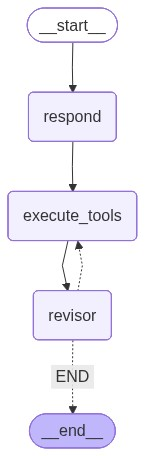

In [91]:
app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [92]:
responses = app.invoke(
    """I'm pre-diabetic and need to lower my blood sugar, and I have heart issues.
    What breakfast foods should I eat and avoid"""
)
# instead of above invoking, below pattern could also be used
# responses = app.invoke([HumanMessage(content="""Write a linkedin post on completing langgraph course from coursera""")])


In [93]:
responses

[HumanMessage(content="I'm pre-diabetic and need to lower my blood sugar, and I have heart issues.\n    What breakfast foods should I eat and avoid", id='81b30db9-a7b2-45b8-ab1e-144d41a69b5c'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_FkHA4OVpKtHfKX5aAIXRbXg9', 'function': {'arguments': '{"answer": "For someone who is pre-diabetic and has heart issues, breakfast choices should focus on foods that help control blood sugar levels and promote heart health. Recommended foods include oatmeal, which is high in soluble fiber and can help stabilize blood sugar; eggs, especially boiled or poached, as they are a good source of protein without added carbs; and vegetables like spinach or tomatoes, which are low in calories and carbs but rich in nutrients. Nuts and seeds, such as almonds or chia seeds, can also be beneficial in moderation, providing healthy fats and fiber. Whole-grain toast or whole-grain cereals are preferable over refined grains because they have a lo

In [97]:
# Final Answer
responses[-1]

AIMessage(content='{\n  "answer": "For managing pre-diabetes and heart health, prioritize a breakfast rich in fiber, healthy fats, and lean proteins. Options include oatmeal topped with nuts and seeds, which provide fiber and healthy fats; eggs prepared by boiling or poaching for high-quality protein; and vegetables like spinach, tomatoes, or peppers that are nutrient-dense and low in sugar. Whole-grain toast or cereals are better than refined grains. Incorporate healthy fats from avocados or nuts, and hydrate with water or herbal teas. Avoid sugary cereals, pastries, white bread, processed meats, fried foods, and fruit juices, as they can cause blood sugar spikes and harm heart health. Meal prep with minimal added sugars, use baking or steaming, and control portion sizes to maintain blood sugar stability. Regularly consult your healthcare provider for personalized guidance to effectively manage your conditions.",\n  "reflection": {\n    "missing": "Specific details about your current 

#### Our response/conversation Chain

Human -> AI(Responder) -> 2 Tool_Calls(web search) -> AI(revisor) --> Tool_Call(Web Search) --> AI(revisor) --> Tool_Call(Web Search) --> AI(revisor)